## CA04 – Ensemble Models

**PROGRAM STRUCTURE DIAGRAM**

    MAIN PROGRAM

FUNCTION 1: Data Preparation & Reproducibility
- Load dataset
- Recreate cleaning & transformations
- Implement encoding, train-test spplit
- Verify sapps
- ad integrity and integrity

FUNCTION 2: Random Forest Modeling + Analysis
- Build default RandonForest model
- Iterate over n_estimators
- Compute Accuragy and AUC
- Generate both graphs

FUNCTION 4: Gradient Boost Modeling + Analysis
- Train Gradient Boost model
- Iterate over n_estimators
- Plot Accuracy vs n_estimators
- Plot AUC vs n_estimators

FUNCTION 5: XGBoost Modeling + anlysis
- Train XOBoost model
- Evaluate Accuracy a and AUC
- Plot both graphs
- Identify optimal estimator

FUNCTION 6: Performance Comparison + Final Testing
- Create summary table
- Add train vs test curves
- Add runtime comparison
- Provide analysis

==== END PROGRAM ====

In [ ]:
# import libraries
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

import matplotlib.pyplot as plt

%matplotlib inline


Data qauality analsysis is already done on the dataset which was used previously for a Decison Tree Algorithm
You may review from this script (https://github.com/pdansoabiam/BSAN_6070_repo/blob/main/CA03/pda_ah_CA03_DT.ipynb)

In [ ]:
# import census_data as dataframe

# Data source provided in instructions
data_url = "https://github.com/ArinB/MSBA-CA-03-Decision-Trees/blob/master/census_data.csv?raw=true"

# Read directly from GitHub
dtree_df = pd.read_csv(data_url)

# Check dataset shape
print("Dataset shape:", dtree_df.shape)

# Display first 5 rows
dtree_df.head(2)


Dataset shape: (48842, 11)


,hours_per_week_bin,occupation_bin,msr_bin,capital_gl_bin,race_sex_bin,education_num_bin,education_bin,workclass_bin,age_bin,flag,y
0,b. 31-40,b. Mid - Low,b. Mid,c. > 0,c. High,c. 13,c. Bachelors,b. income,d. 36-40 & 56-60,train,0
1,a. 0-30,e. High,c. High,a. = 0,c. High,c. 13,c. Bachelors,b. income,e. 40-55,train,0


**Data cleaning and transformations**



**Remove Duplicate Records**

DQA detected **40,012 duplicate rows** (80%+ of the dataset). This prevents risk of:
- inflating model performance (the model “sees” the same rows repeatedly),
- increasing overfitting,
- distorting class distribution.

**Action:** remove duplicate rows and confirm the dataset shape before/after.


In [ ]:

# --- Before: baseline checks ---
print("Shape BEFORE dropping duplicates:", dtree_df.shape)

# Count how many duplicate rows exist (excluding the first occurrence)
dup_count = dtree_df.duplicated().sum()
print("Number of duplicate rows detected:", dup_count)

# --- Remove duplicates ---
# drop_duplicates() keeps the first occurrence and removes repeated rows
dtree_df_clean = dtree_df.drop_duplicates().reset_index(drop=True)

# --- After: confirm result ---
print("Shape AFTER dropping duplicates:", dtree_df_clean.shape)
print("Duplicates remaining AFTER:", dtree_df_clean.duplicated().sum())

# verify class distribution didn't shift unexpectedly
print("\nClass distribution BEFORE (y):")
print(dtree_df["y"].value_counts(normalize=True))

print("\nClass distribution AFTER (y):")
print(dtree_df_clean["y"].value_counts(normalize=True))


Shape BEFORE dropping duplicates: (48842, 11)
Number of duplicate rows detected: 40012
Shape AFTER dropping duplicates: (8830, 11)
Duplicates remaining AFTER: 0

Class distribution BEFORE (y):
y
0    0.760718
1    0.239282
Name: proportion, dtype: float64

Class distribution AFTER (y):
y
0    0.678596
1    0.321404
Name: proportion, dtype: float64


**Train/Test Split Using Provided Split Column (flag)**

The dataset includes a column (`flag`) that indicates whether each row belongs to the training set or test set. We split the dataset programmatically based on this column.

Subsequenstly, since this column indicates dataset partitioning rather than meaningful predictive information, including this feature in model training would:
- Introduce data leakage,
- Artificially inflate performance,
- Cause the model to learn dataset split patterns instead of real signals.

Therefore, the `flag` column must be removed prior to modeling.


In [ ]:
# Use the de-duplicated dataset created in Step 1
df = dtree_df_clean.copy()

# Split using the provided flag column
train_df = df[df["flag"].str.lower() == "train"].copy()
test_df  = df[df["flag"].str.lower() == "test"].copy()

print("Train shape (raw):", train_df.shape)
print("Test shape (raw):", test_df.shape)

# Drop the flag column AFTER splitting (to prevent leakage)
train_df = train_df.drop(columns=["flag"])
test_df  = test_df.drop(columns=["flag"])

# Separate target and features
y_train = train_df["y"].astype(int)
X_train = train_df.drop(columns=["y"])

y_test  = test_df["y"].astype(int)
X_test  = test_df.drop(columns=["y"])

print("\nX_train shape:", X_train.shape, "| y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape, "| y_test shape:", y_test.shape)


Train shape (raw): (5106, 11)
Test shape (raw): (3724, 11)

X_train shape: (5106, 9) | y_train shape: (5106,)
X_test shape: (3724, 9) | y_test shape: (3724,)


**Ordinal Encoding for Ordered Binned Variables**

Several features in this dataset are binned categorical variables that imply natural ordering. Examples include:

- hours_per_week_bin
- age_bin
- education_num_bin
- capital_gl_bin
- msr_bin

Although currently stored as string categories (e.g., "a. 0-30", "b. 31-40"), these bins reflect increasing magnitude.

If treated as nominal categories, the model will ignore their inherent order, leading to information loss.

Therefore, we apply ordinal encoding to preserve ranking information.


In [ ]:
# Inspect Unique Values First

ordinal_columns = [
    "hours_per_week_bin",
    "age_bin",
    "education_num_bin",
    "capital_gl_bin",
    "msr_bin"]

for col in ordinal_columns:
    print(f"\n{col} unique values:")
    print(sorted(dtree_df_clean[col].unique()))



hours_per_week_bin unique values:
['a. 0-30', 'b. 31-40', 'c. 71-100', 'd. 41-50 & 61-70', 'e. 51-60']

age_bin unique values:
['a. 0-25', 'b. 26-30 & 71-100', 'c. 31-35 & 61-70', 'd. 36-40 & 56-60', 'e. 40-55']

education_num_bin unique values:
['a. 0-8', 'b. 9-12', 'c. 13', 'd. 14', 'e. 15+']

capital_gl_bin unique values:
['a. = 0', 'b. < 0', 'c. > 0']

msr_bin unique values:
['a. Low', 'b. Mid', 'c. High']


In [ ]:
## Apply Ordinal Encoding (Post-Split)

# Function to convert 'a.', 'b.', 'c.' into ordinal numbers
def ordinal_encode(series):
    return series.str[0].map({
        "a": 1,
        "b": 2,
        "c": 3,
        "d": 4,
        "e": 5})

# Define ordinal columns again (if needed)
ordinal_columns = [
    "hours_per_week_bin",
    "age_bin",
    "education_num_bin",
    "capital_gl_bin",
    "msr_bin"]

# Apply encoding to TRAIN
for col in ordinal_columns:
    X_train[col] = ordinal_encode(X_train[col])

# Apply encoding to TEST (same logic)
for col in ordinal_columns:
    X_test[col] = ordinal_encode(X_test[col])

# Verify transformation
print(X_train[ordinal_columns].head(2))



   hours_per_week_bin  age_bin  education_num_bin  capital_gl_bin  msr_bin
0                   2        4                  3               3        2
1                   1        5                  3               1        3


**One-Hot Encode Nominal Categorical Variables**

After ordinal encoding ordered bins (e.g., `age_bin`, `hours_per_week_bin`), the remaining categorical features are **nominal**, their categories do **not** have a natural ranking.

Examples include:
- `occupation_bin`
- `race_sex_bin`
- `workclass_bin`
- `education_bin`

For the nominal variables, **one-hot encoding** is used to convert categories into binary indicator columns (0/1).  
This prevents the model from assuming an artificial order among categories.


In [ ]:

# --- Identify nominal columns to one-hot encode ---
# (These are the categorical features that should NOT be ordinal-encoded)

nominal_cols = ["occupation_bin", "race_sex_bin", "workclass_bin", "education_bin"]

# Sanity check: confirm columns exist in X_train (and X_test)
print("Nominal columns found in X_train:", [c for c in nominal_cols if c in X_train.columns])
print("Nominal columns found in X_test :", [c for c in nominal_cols if c in X_test.columns])

# One-hot encode TRAIN and TEST separately
X_train_encoded = pd.get_dummies(X_train, columns=nominal_cols, drop_first=True)
X_test_encoded  = pd.get_dummies(X_test,  columns=nominal_cols, drop_first=True)

# Align TEST to TRAIN columns so the model sees the same feature set
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0)

# Confirm final shapes
print("\nShape BEFORE encoding (X_train):", X_train.shape)
print("Shape AFTER encoding  (X_train):", X_train_encoded.shape)

print("\nShape BEFORE encoding (X_test):", X_test.shape)
print("Shape AFTER encoding  (X_test):", X_test_encoded.shape)

# Preview
X_train_encoded.head(2)


Nominal columns found in X_train: ['occupation_bin', 'race_sex_bin', 'workclass_bin', 'education_bin']
Nominal columns found in X_test : ['occupation_bin', 'race_sex_bin', 'workclass_bin', 'education_bin']

Shape BEFORE encoding (X_train): (5106, 9)
Shape AFTER encoding  (X_train): (5106, 16)

Shape BEFORE encoding (X_test): (3724, 9)
Shape AFTER encoding  (X_test): (3724, 16)


,hours_per_week_bin,msr_bin,capital_gl_bin,education_num_bin,age_bin,occupation_bin_b. Mid - Low,occupation_bin_c. Mid - Mid,occupation_bin_d. Mid - High,occupation_bin_e. High,race_sex_bin_b. Mid,race_sex_bin_c. High,workclass_bin_b. income,education_bin_b. Mid,education_bin_c. Bachelors,education_bin_d. Masters,education_bin_e. High
0,2,2,3,3,4,True,False,False,False,False,True,True,False,True,False,False
1,1,3,1,3,5,False,False,False,True,False,True,True,False,True,False,False


**What this code does**

- **`pd.get_dummies()`** converts each nominal category into its own 0/1 column.
- **`drop_first=True`** drops one category per original feature to avoid the *dummy variable trap*
  (important for linear models; harmless for trees but still a good default).
- The dataset becomes fully numeric and ready for modeling.


X_encoded.dtypes.value_counts()


Separation of predictor feature variables (X) and Target variable (y) is done.

To ensure the target (y) is not accidentally used as a predictor


In [ ]:
## Verification Block before modeling

print("Final TRAIN feature shape:", X_train_encoded.shape)
print("Final TRAIN target shape :", y_train.shape)

print("Final TEST feature shape :", X_test_encoded.shape)
print("Final TEST target shape  :", y_test.shape)



Final TRAIN feature shape: (5106, 16)
Final TRAIN target shape : (5106,)
Final TEST feature shape : (3724, 16)
Final TEST target shape  : (3724,)


**Find optimal value of key Ensemble Method Hyperparameter by creating these line graphs;**
- Accuracy Vs. n_estimators
- AUC Vs. n_estimators

**Hyperparameter Tuning (Random Forest – n_estimators)**

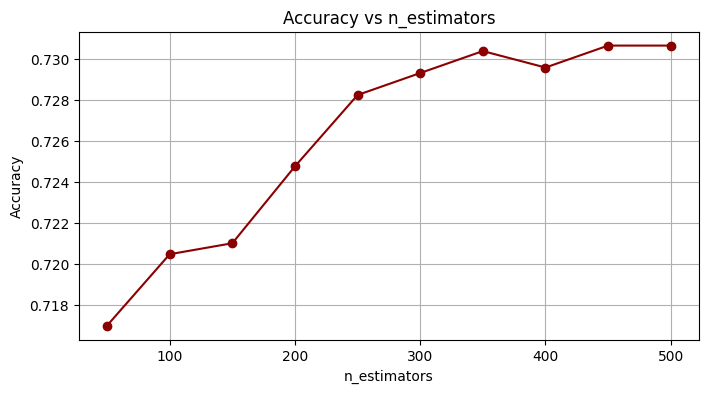

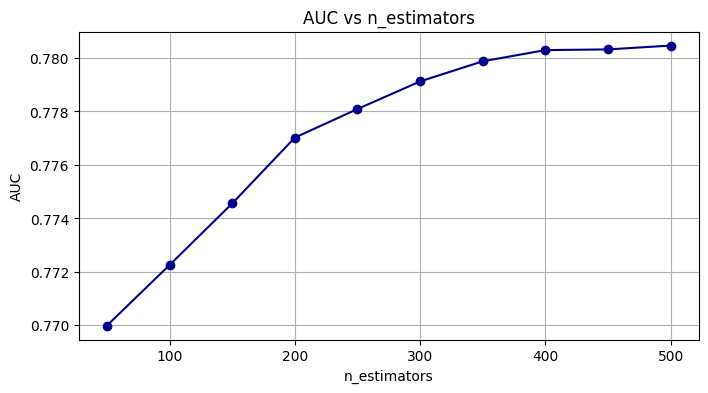

In [ ]:
# Accuracy vs n_estimators

# Store results
acc_results = []
auc_results = []

# Required estimator range from instruction
n_estimator_options = [50,100,150,200,250,300,350,400,450,500]

for n in n_estimator_options:
    model = RandomForestClassifier(
        n_estimators=n,
        random_state=101)

    model.fit(X_train_encoded, y_train)

    # Predictions
    y_pred = model.predict(X_test_encoded)
    y_prob = model.predict_proba(X_test_encoded)[:,1]  # for AUC

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    acc_results.append(acc)
    auc_results.append(auc)

# Plot Accuracy
plt.figure(figsize=(8,4))
pd.Series(acc_results, index=n_estimator_options).plot(
    marker='o',
    color='darkred')
plt.title("Accuracy vs n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# Plot AUC
plt.figure(figsize=(8,4))
pd.Series(auc_results, index=n_estimator_options).plot(
    marker='o',
    color='darkblue')
plt.title("AUC vs n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("AUC")
plt.grid(True)
plt.show()

## Answer for questions below from the Random Forest model output:
1. Write your observations about the Classifier’s behavior with respect to the number of estimators

The classifier shows steady improvement in both Accuracy and AUC as the number of estimators increases from 50 to approximately 350. Beyond this point, both curves begin to plateau, indicating that additional trees contribute very little performance gain

2. Is there an optimal value of the estimator within the given range?

The maximum observed Accuracy occurs around 450–500 estimators; however, the incremental improvement beyond 350–400 estimators is negligible. Therefore, the optimal value of the key hyperparameter n_estimators is approximately 350–450, as it provides near-maximum predictive performance while maintaining computational efficiency

**Random Forest (RF) Modeling + Analysis**
Train final RF model using optimal n
Show final performance (Accuracy + AUC)

In [ ]:
# Final model using near-optimal n_estimators (350–450)

rf_final = RandomForestClassifier(
    n_estimators=450,      # <- using 450
    random_state=101,
    n_jobs=-1   )           # uses all CPU cores for faster training

rf_final.fit(X_train_encoded, y_train)

y_pred_final = rf_final.predict(X_test_encoded)
y_prob_final = rf_final.predict_proba(X_test_encoded)[:, 1]

print("Final Accuracy:", accuracy_score(y_test, y_pred_final))
print("Final AUC:", roc_auc_score(y_test, y_prob_final))

Final Accuracy: 0.7306659505907627
Final AUC: 0.7803229563990646


**Hyperparameter Tuning (AdaBoost – n_estimators)**

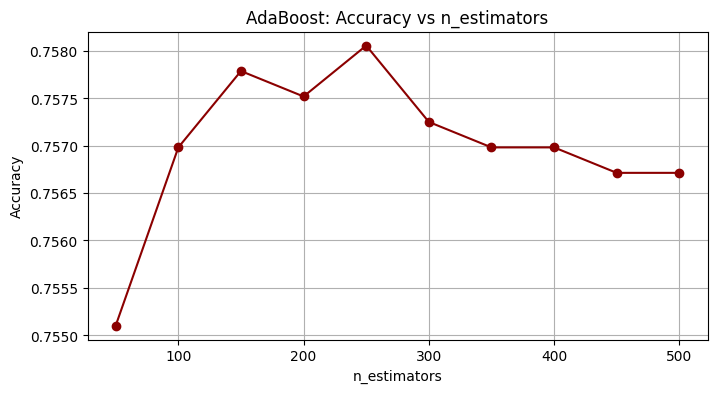

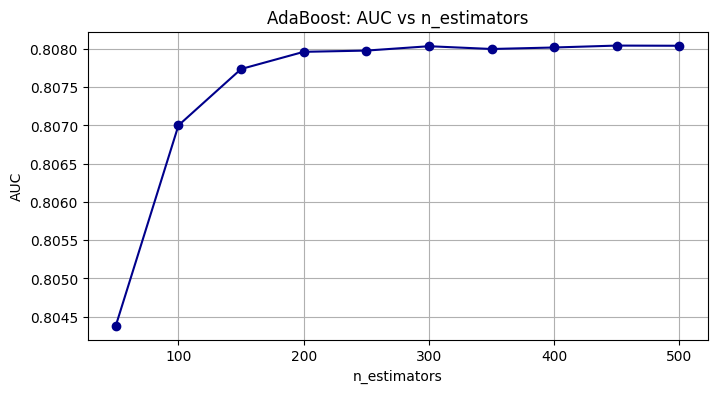

In [ ]:
# Store results
acc_results = []
auc_results = []

# Required estimator range from instruction
n_estimator_options = [50,100,150,200,250,300,350,400,450,500]

for n in n_estimator_options:
    model = AdaBoostClassifier(
        n_estimators=n,
        random_state=101)

    model.fit(X_train_encoded, y_train)

    # Predictions
    y_pred = model.predict(X_test_encoded)
    y_prob = model.predict_proba(X_test_encoded)[:, 1]  # for AUC

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    acc_results.append(acc)
    auc_results.append(auc)

# Plot Accuracy
plt.figure(figsize=(8,4))
pd.Series(acc_results, index=n_estimator_options).plot(
    marker='o',
    color='darkred')
plt.title("AdaBoost: Accuracy vs n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# Plot AUC
plt.figure(figsize=(8,4))
pd.Series(auc_results, index=n_estimator_options).plot(
    marker='o',
    color='darkblue')

plt.title("AdaBoost: AUC vs n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("AUC")
plt.grid(True)
plt.show()

## Answer for questions below from the Adaboost model output

1. Write your observations about the Classifier’s behavior with respect to the number
of estimators

From the Accuracy plot, AdaBoost shows a strong improvement between 50 and approximately 150-250
estimators. Accuracy peaks around 250 estimators (~0.758) and then begins to slightly decline or fluctuate
as more estimators are added.

From the AUC plot, performance increases rapidly up to around 200-300 estimators, after which it stabilizes
around 0.808. Beyond 300 estimators, the improvement is negligible and the curve becomes almost flat.

This behavior reflects the nature of AdaBoost:
. Initially, adding more weak learners improves performance because each new learner focuses on
correcting previous errors.
. After a certain point, additional estimators provide diminishing returns.
. Slight performance decline in accuracy beyond 250 may indicate mild sensitivity to noise or overfitting
effects.


2. Is there an optimal value of the estimator within the given range?

Yes, there is an optimal value within the given range. Based on the plots:
. Accuracy peaks around 250 estimators.
. AUC stabilizes around 200-300 estimators.

Although AUC continues marginally improving after 300, the improvement is extremely small. Therefore, the
optimal range is approximately 250-300 estimators, since this region achieves maximum or near-maximum
predictive performance while avoiding unnecessary computational complexity. Thus, a practical optimal value would be:
n_estimators = 250 (or 300)
This provides the best trade-off between performance and model efficiency.

**AdaBoost Modeling + Analysis**
Train final RF model using optimal n
Show final performance (Accuracy + AUC)

In [ ]:
# Final AdaBoost model using optimal n_estimators (250)

from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

ada_final = AdaBoostClassifier(
    n_estimators=250,   # <- using 250
    random_state=101)

ada_final.fit(X_train_encoded, y_train)

# Predictions
y_pred_final = ada_final.predict(X_test_encoded)
y_prob_final = ada_final.predict_proba(X_test_encoded)[:, 1]

# Final metrics
print("Final Accuracy:", accuracy_score(y_test, y_pred_final))
print("Final AUC:", roc_auc_score(y_test, y_prob_final))


Final Accuracy: 0.7580558539205156
Final AUC: 0.8079783076499065


**Gradient Boost Modeling + Analysis**

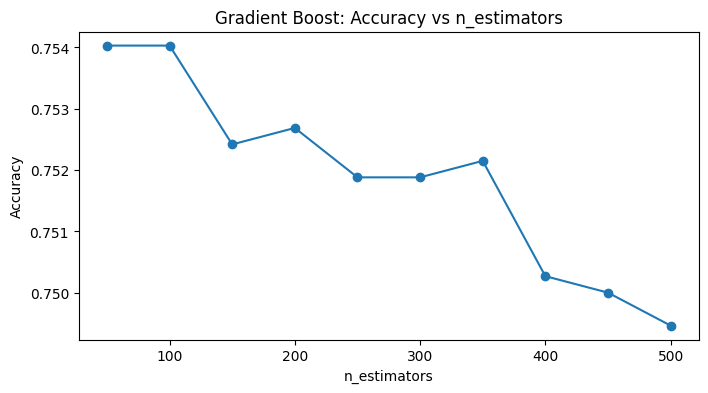

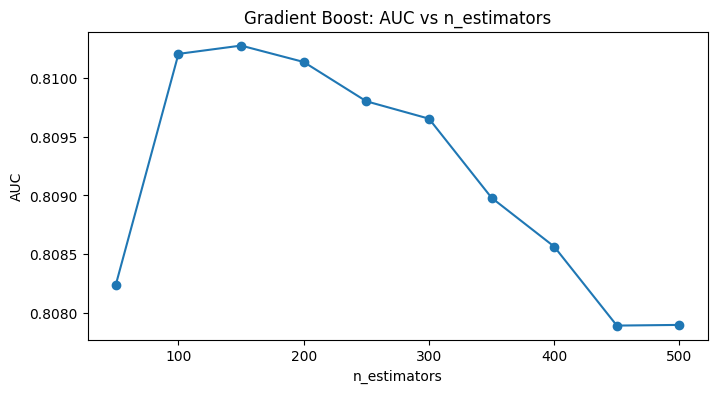

In [ ]:
!pip install xgboost

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt

n_estimators_list = [50,100,150,200,250,300,350,400,450,500]

gb_accuracy = []
gb_auc = []

for n in n_estimators_list:
    gb = GradientBoostingClassifier(n_estimators=n, random_state=101)
    gb.fit(X_train_encoded, y_train)

    y_pred = gb.predict(X_test_encoded)
    y_prob = gb.predict_proba(X_test_encoded)[:,1]

    gb_accuracy.append(accuracy_score(y_test, y_pred))
    gb_auc.append(roc_auc_score(y_test, y_prob))

plt.figure(figsize=(8,4))
plt.plot(n_estimators_list, gb_accuracy, marker='o')
plt.title("Gradient Boost: Accuracy vs n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.show()

plt.figure(figsize=(8,4))
plt.plot(n_estimators_list, gb_auc, marker='o')
plt.title("Gradient Boost: AUC vs n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("AUC")
plt.show()

As the number of estimators increases from 50 to around 150, both Accuracy and AUC improve slightly. The model performs best in the early to mid range of estimators. After 150 - 200 estimators, both Accuracy and AUC begin to decline gradually, indicating potential overfitting as more trees are added.

The Accuracy peaks around 50 - 100 estimators (0.754) and then decreases toward 500 estimators. Similarly, AUC reaches its highest value around 100 - 150 estimators (0.811 - 0.812) before slowly declining.

The optimal number of estimators appears to be around 100 - 150, where AUC is highest and Accuracy is near its peak. Beyond this range, performance decreases slightly while computational cost increases, making higher values inefficient.

**XGBoost Modeling + Analysis**

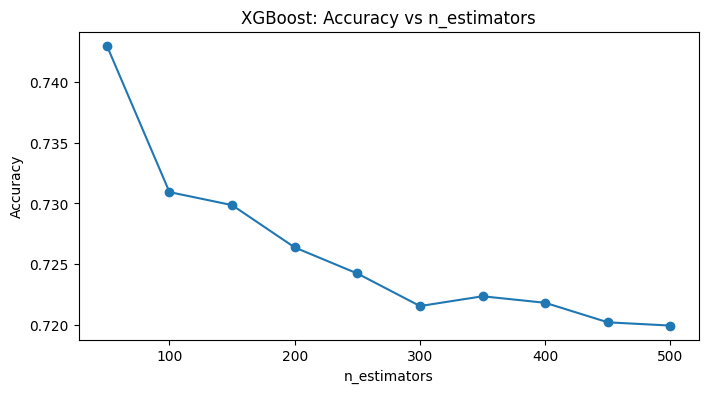

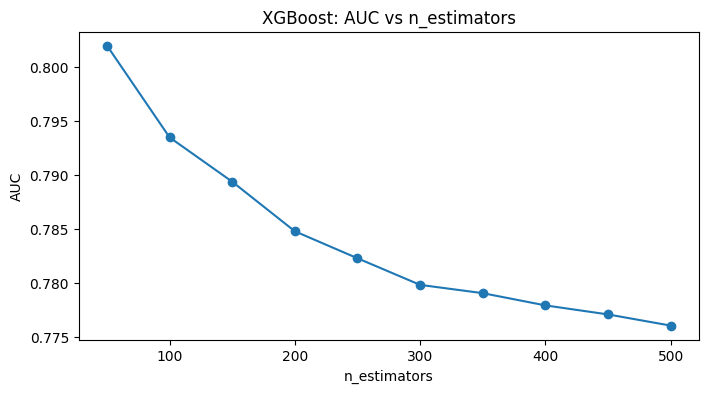

In [ ]:
!pip -q install xgboost

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt

n_estimators_list = [50,100,150,200,250,300,350,400,450,500]

xgb_accuracy = []
xgb_auc = []

for n in n_estimators_list:
    xgb = XGBClassifier(
        n_estimators=n,
        random_state=101,
        eval_metric="logloss"
    )

    xgb.fit(X_train_encoded, y_train)

    y_pred = xgb.predict(X_test_encoded)
    y_prob = xgb.predict_proba(X_test_encoded)[:,1]

    xgb_accuracy.append(accuracy_score(y_test, y_pred))
    xgb_auc.append(roc_auc_score(y_test, y_prob))

plt.figure(figsize=(8,4))
plt.plot(n_estimators_list, xgb_accuracy, marker='o')
plt.title("XGBoost: Accuracy vs n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.show()

plt.figure(figsize=(8,4))
plt.plot(n_estimators_list, xgb_auc, marker='o')
plt.title("XGBoost: AUC vs n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("AUC")
plt.show()

As the number of estimators increases, both Accuracy and AUC steadily decline. The model performs best at the lowest value of n_estimators (50). Accuracy starts at approximately 0.743 at 50 estimators and decreases gradually toward about 0.720 at 500 estimators.

Similarly, AUC is highest at around 0.802 for 50 estimators and consistently declines as more estimators are added, reaching approximately 0.776 at 500 estimators. This suggests that increasing the number of trees leads to overfitting and reduced generalization performance on the test set.

The optimal value of n_estimators for XGBoost within the tested range is 50, as it produces the highest Accuracy and AUC. Beyond this point, performance declines while computational cost increases, making larger estimator values inefficient for this dataset.

**Performance Comparison**

**For the best values of Accuracy and AUC for four models (Random Forest, AdaBoost, Gradient Boost, XGB) in the previous steps, fill up the following table:**

|                | Random Forest | AdaBoost | Gradient Boost | XGB   |
|----------------|--------------|----------|----------------|-------|
| **Accuracy**   | 0.7307       | 0.7580   | 0.7540         | 0.7430 |
| **AUC**        | 0.7803       | 0.8079   | 0.8112         | 0.8020 |


Gradient Boost achieved the highest AUC (0.8112), showing the strongest overall classification performance. AdaBoost produced the highest Accuracy (0.7580) but slightly lower AUC than Gradient Boost. XGBoost performed moderately, while Random Forest had the lowest results. Overall, boosting-based models outperformed Random Forest, with Gradient Boost performing best overall.

**AI was used as colloboration on this project**

                        _____________________END OF MODEL__________________